In [100]:
import re, time
import pandas as pd
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import WebDriverException
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import numpy as np

In [101]:
BASE = "https://www.multitrabajos.com/listado-empresas?page={p}"
TOTAL_PAGINAS = 10
RE_AVISOS = re.compile(r"(\d+)\s+avisos?\s+activos?", re.IGNORECASE)
RE_EMPLEADOS = re.compile(r"Entre\s+(.+?)\s+empleados", re.IGNORECASE)


In [102]:
PROVINCIAS_EC = {
    "Azuay","Bolívar","Cañar","Carchi","Chimborazo","Cotopaxi","El Oro","Esmeraldas",
    "Galápagos","Guayas","Imbabura","Loja","Los Ríos","Manabí","Morona Santiago",
    "Napo","Orellana","Pastaza","Pichincha","Santa Elena","Santo Domingo de los Tsáchilas",
    "Sucumbíos","Tungurahua","Zamora Chinchipe"
}

In [103]:
def parse_card_text(text: str):
    lines = [ln.strip() for ln in text.split("\n") if ln.strip()]

    empresa = lines[0] if lines else None
    avisos = None
    empleados = None
    provincia = None
    actividad = None

    for ln in lines:
        m = RE_AVISOS.search(ln)
        if m:
            avisos = int(m.group(1))

        m2 = RE_EMPLEADOS.search(ln)
        if m2:
            empleados = m2.group(1).strip()

        if ln in PROVINCIAS_EC:
            provincia = ln

    for ln in lines:
        l = ln.lower()
        if ln == empresa:
            continue
        if "avisos" in l or "empleados" in l:
            continue
        if ln in PROVINCIAS_EC:
            continue
        if l in ("seguir", "empresa busca activamente"):
            continue
        if len(ln) <= 60:
            actividad = ln
            break

    return {
        "Empresa": empresa,
        "AvisosActivos": avisos,
        "Actividad": actividad,
        "Provincia": provincia,
        "Empleados": empleados,
    }


In [104]:
def recrear_driver():
    global driver
    try:
        driver.quit()
    except Exception:
        pass

    options = Options()
    options.add_argument("--start-maximized")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(options=options)
    return driver

In [105]:
def extraer_pagina(p, scrolls=2):
    url = BASE.format(p=p)
    driver.get(url)

    wait = WebDriverWait(driver, 25)
    wait.until(EC.presence_of_element_located(
        (By.XPATH, "//*[contains(., 'avisos activos') or contains(., 'avisos activo')]")
    ))
    time.sleep(2)

    for _ in range(scrolls):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)

    cards = driver.find_elements(By.XPATH, "//a[contains(., 'avisos activos') or contains(., 'avisos activo')]")

    rows = []
    seen = set()
    for c in cards:
        t = c.text.strip()
        if not t or t in seen:
            continue
        seen.add(t)
        row = parse_card_text(t)
        row["Page"] = p
        rows.append(row)

    return rows

In [106]:
todos = []
for p in range(1, TOTAL_PAGINAS + 1):
    print(f"\n Página {p}/{TOTAL_PAGINAS}")

    try:
        rows = extraer_pagina(p, scrolls=2)
        print("filas:", len(rows))
        todos.extend(rows)

    except WebDriverException as e:
        print(" Driver se cayó. Recreando y reintentando 1 vez...")
        recrear_driver()

        try:
            rows = extraer_pagina(p, scrolls=2)
            print(" reintento OK | filas:", len(rows))
            todos.extend(rows)
        except Exception as e2:
            print("reintento falló:", e2)

    except Exception as e:
        print("error:", e)

df = pd.DataFrame(todos)
df = df.drop_duplicates(subset=["Empresa"]).reset_index(drop=True)

df.to_csv("multitrabajos_empresas.csv", index=False, encoding="utf-8-sig")
print("\n Guardado: multitrabajos_empresas.csv")


df.head(198)


 Página 1/10
filas: 23

 Página 2/10
filas: 23

 Página 3/10
filas: 23

 Página 4/10
filas: 23

 Página 5/10
filas: 23

 Página 6/10
filas: 23

 Página 7/10
filas: 23

 Página 8/10
filas: 23

 Página 9/10
filas: 23

 Página 10/10
filas: 23

 Guardado: multitrabajos_empresas.csv


,Empresa,AvisosActivos,Actividad,Provincia,Empleados,Page
0,De Prati,2,4.4,Guayas,NaN,1
1,Pronaca,11,4.5,Pichincha,NaN,1
2,CORPORACION EL ROSADO,20,4.2,Guayas,NaN,1
3,DHL Express,1,-,Pichincha,51 y 150,1
4,GrupoLucky Ecuador,72,-,Guayas,501 y 1000,1
...,...,...,...,...,...,...
193,O'conor Consulting,11,Consultora de Recursos Humanos,Pichincha,1 y 10,10
194,ZITROCONSULTING S.A.S,11,Servicios,Pichincha,1 y 10,10
195,Diego Salazar,10,Consultora de Recursos Humanos,Pichincha,11 y 50,10
196,GESTION EXTERNA GESTIONA GTX S.A.,10,Financiera,Pichincha,301 y 500,10


## limpieza y transformación de datos 

In [107]:
df_clean = df.copy()

In [ ]:

for col in ["Empresa", "Actividad", "Provincia", "Empleados"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean["Empresa"] = df_clean["Empresa"].str.title()
df_clean["Actividad"] = df_clean["Actividad"].str.title()
df_clean["Provincia"] = df_clean["Provincia"].str.title()


df_clean["AvisosActivos"] = pd.to_numeric(df_clean["AvisosActivos"], errors="coerce")


df_clean["Empleados_Min"] = (
    df_clean["Empleados"]
    .str.extract(r"(\d+)")
)

df_clean["Empleados_Max"] = (
    df_clean["Empleados"]
    .str.extract(r"\d+\D+(\d+)")
)

df_clean["Empleados_Min"] = pd.to_numeric(df_clean["Empleados_Min"], errors="coerce")
df_clean["Empleados_Max"] = pd.to_numeric(df_clean["Empleados_Max"], errors="coerce")

df_clean = df_clean.drop_duplicates(subset=["Empresa"])


print( df_clean.shape)
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())

df_clean.head(10)

Dimensiones: (198, 8)

Valores nulos por columna:
Empresa           0
AvisosActivos     0
Actividad         2
Provincia        19
Empleados        11
Page              0
Empleados_Min    11
Empleados_Max    11
dtype: int64


,Empresa,AvisosActivos,Actividad,Provincia,Empleados,Page,Empleados_Min,Empleados_Max
0,De Prati,2,4.4,Guayas,NaN,1,NaN,NaN
1,Pronaca,11,4.5,Pichincha,NaN,1,NaN,NaN
2,Corporacion El Rosado,20,4.2,Guayas,NaN,1,NaN,NaN
3,Dhl Express,1,-,Pichincha,51 y 150,1,51.0,150.0
4,Grupolucky Ecuador,72,-,Guayas,501 y 1000,1,501.0,1000.0
5,Danec,14,-,Pichincha,1001 y 5000,1,1001.0,5000.0
6,Banco Internacional,2,-,Pichincha,1001 y 5000,1,1001.0,5000.0
7,"Corporación Proauto (Proauto, Mirasol, E.Maulme)",9,-,Pichincha,501 y 1000,1,501.0,1000.0
8,Quifatex Ecuador,9,-,Pichincha,501 y 1000,1,501.0,1000.0
9,Finanzas Corporativas,5,-,Cotopaxi,11 y 50,1,11.0,50.0


In [109]:
df_sin_nulos = df_clean.dropna()
df_sin_nulos.head()

,Empresa,AvisosActivos,Actividad,Provincia,Empleados,Page,Empleados_Min,Empleados_Max
3,Dhl Express,1,-,Pichincha,51 y 150,1,51.0,150.0
4,Grupolucky Ecuador,72,-,Guayas,501 y 1000,1,501.0,1000.0
5,Danec,14,-,Pichincha,1001 y 5000,1,1001.0,5000.0
6,Banco Internacional,2,-,Pichincha,1001 y 5000,1,1001.0,5000.0
7,"Corporación Proauto (Proauto, Mirasol, E.Maulme)",9,-,Pichincha,501 y 1000,1,501.0,1000.0


In [110]:
df_sin_nulos_f=df_sin_nulos.copy()
df_sin_nulos_f["provincia"]= df_sin_nulos_f["Provincia"].fillna("No especificado")
df_sin_nulos_f.head()

,Empresa,AvisosActivos,Actividad,Provincia,Empleados,Page,Empleados_Min,Empleados_Max,provincia
3,Dhl Express,1,-,Pichincha,51 y 150,1,51.0,150.0,Pichincha
4,Grupolucky Ecuador,72,-,Guayas,501 y 1000,1,501.0,1000.0,Guayas
5,Danec,14,-,Pichincha,1001 y 5000,1,1001.0,5000.0,Pichincha
6,Banco Internacional,2,-,Pichincha,1001 y 5000,1,1001.0,5000.0,Pichincha
7,"Corporación Proauto (Proauto, Mirasol, E.Maulme)",9,-,Pichincha,501 y 1000,1,501.0,1000.0,Pichincha


In [111]:
df_sin_nulos_f['Empleados_Min']= df_sin_nulos_f['Empleados_Min'].fillna(0).astype(int)
df_sin_nulos_f['Empleados_Max']= df_sin_nulos_f['Empleados_Max'].fillna(0).astype(int)

In [112]:
df_sin_nulos_f.info()

<class 'pandas.DataFrame'>
Index: 169 entries, 3 to 197
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Empresa        169 non-null    str  
 1   AvisosActivos  169 non-null    int64
 2   Actividad      169 non-null    str  
 3   Provincia      169 non-null    str  
 4   Empleados      169 non-null    str  
 5   Page           169 non-null    int64
 6   Empleados_Min  169 non-null    int64
 7   Empleados_Max  169 non-null    int64
 8   provincia      169 non-null    str  
dtypes: int64(4), str(5)
memory usage: 13.2 KB


In [113]:
import matplotlib.pyplot as plt

# Agrupar por provincia
prov_empleos = (
    df_sin_nulos_f
    .groupby("Provincia")["AvisosActivos"]
    .sum()
    .sort_values(ascending=False)
)

prov_empleos.head(10)

Provincia
Pichincha           946
Guayas              764
Azuay               182
Tungurahua           48
Loja                 20
Manabí               12
Los Ríos              8
El Oro                5
Cotopaxi              5
Zamora Chinchipe      2
Name: AvisosActivos, dtype: int64

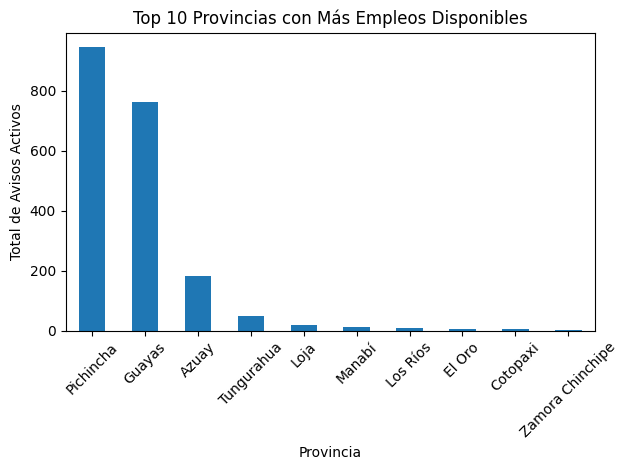

In [114]:
plt.figure()

prov_empleos.head(10).plot(kind="bar")

plt.title("Top 10 Provincias con Más Empleos Disponibles")
plt.xlabel("Provincia")
plt.ylabel("Total de Avisos Activos")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [115]:
top_empresas = (
    df_sin_nulos_f
    .sort_values(by="AvisosActivos", ascending=False)
    .head(10)
)

top_empresas[["Empresa", "AvisosActivos"]]

,Empresa,AvisosActivos
131,Eficacia,241
180,Gerardo Ortiz,118
174,Best Talents Consulting Latam,114
4,Grupolucky Ecuador,72
67,Multitrabajos Staffing,46
83,Marcimex,41
133,Jaher,41
182,Mayer Consulting,39
181,Externa,39
84,Banco Solidario,38


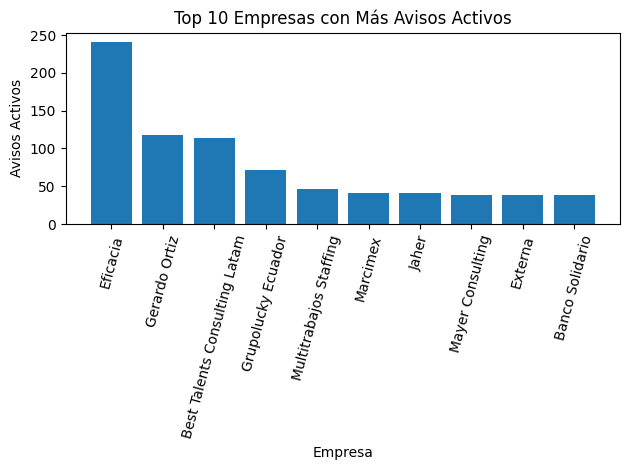

In [117]:
plt.figure()

plt.bar(top_empresas["Empresa"], top_empresas["AvisosActivos"])

plt.title("Top 10 Empresas con Más Avisos Activos")
plt.xlabel("Empresa")
plt.ylabel("Avisos Activos")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()